In [ ]:
# Pull first 5 data entries to look at format, possible issues, and what columns are available for analysis.
import pandas as pd

pd.set_option("display.max_colwidth", None)

df = pd.read_csv("../data/raw/heels_listings.csv")
df.head()

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path
0,v1|327293758920|0,Vintage pinup Stiletto Heels Polka Dot Bow Ankle Strap Open Toe,Heels,40.00,https://api.ebay.com/buy/browse/v1/item/v1%7C327293758920%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/5nYAAeSwan9qcQt6/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_327293758920_0.jpg
1,v1|158096242487|459340279961,Vintage Black Multi-Strap Knee-High Caged Gladiator Heels with Buckle ws1907046,Heels,77.99,https://api.ebay.com/buy/browse/v1/item/v1%7C158096242487%7C459340279961,New with box,https://i.ebayimg.com/images/g/E6kAAeSwws5qW7oE/s-l960.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_158096242487_459340279961.jpg
2,v1|257659835442|0,Vintage Y2K BCBG Strappy Sandals Heels 7.5 FLAWS,Heels,58.98,https://api.ebay.com/buy/browse/v1/item/v1%7C257659835442%7C0,Pre-owned - Fair,https://i.ebayimg.com/images/g/M9MAAeSwwHJqMdjT/s-l960.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_257659835442_0.jpg
3,v1|168350814249|0,Vtg Coup D’etat Camel Color Heel Pumps Size 7.5B,Heels,29.00,https://api.ebay.com/buy/browse/v1/item/v1%7C168350814249%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/jWMAAeSwhANp95MA/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_168350814249_0.jpg
4,v1|398240323736|0,Vintage Salvatore Ferragamo Boutique black leather heel pump women's size 8B,Heels,129.99,https://api.ebay.com/buy/browse/v1/item/v1%7C398240323736%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/nUkAAeSwhQNqbrNw/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_398240323736_0.jpg


In [ ]:
# Check the shape of the dataframe to see how many rows and columns are present.
df.shape

(1162, 8)

In [ ]:
# Pull column names to see what data is available for analysis.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1162 entries, 0 to 1161
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   itemId            1162 non-null   str    
 1   title             1162 non-null   str    
 2   specificCategory  1162 non-null   str    
 3   price             1162 non-null   float64
 4   itemURL           1162 non-null   str    
 5   condition         1162 non-null   str    
 6   imageURL          1162 non-null   str    
 7   image_local_path  1160 non-null   str    
dtypes: float64(1), str(7)
memory usage: 72.8 KB


In [ ]:
# Look at summary statistics
df.describe()

,price
count,1162.000000
mean,70.788012
std,82.661002
min,7.000000
25%,26.550000
50%,40.000000
75%,77.057500
max,899.000000


Large range is not necessarily an anomaly given the presence of luxury heels. 
Interesting to see that most shoes average around ~$70; this is most likely representative of eBay's user/seller audience.
I would expect options like TheRealReal to have more luxury shoes, and a higher mean, and Depop to be similar to eBay's range.

In [5]:
df.isnull().sum()

itemId              0
title               0
specificCategory    0
price               0
itemURL             0
condition           0
imageURL            0
image_local_path    2
dtype: int64

In [ ]:
# Checking both ends of data to see outliers and possible data entry errors.
df.sort_values("price", ascending=True).head(10)

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path
1083,v1|168371212741|0,VTG Y2K Charlotte Russe Silver Braided Sandals Summer Beach Greek Toga Metallic,Sandals,7.00,https://api.ebay.com/buy/browse/v1/item/v1%7C168371212741%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/G64AAeSwyFxqA7HL/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_168371212741_0.jpg
950,v1|327292428516|0,Crown Vintage Remy Womend Sz 7.5 Strappy Sandals Black Faux Leather Buckle Shoes,Sandals,7.99,https://api.ebay.com/buy/browse/v1/item/v1%7C327292428516%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/RnYAAeSwGs1qb9sZ/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_327292428516_0.jpg
97,v1|117293725136|0,Vintage Sam & Libby High Heel Dress Sandals 6M Excellent Condition Black Velvet,Heels,7.99,https://api.ebay.com/buy/browse/v1/item/v1%7C117293725136%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/ZQYAAeSwTSpo1D34/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_117293725136_0.jpg
652,v1|257247151573|0,Vintage high heels - metallic gold material - great condition,Heels,8.00,https://api.ebay.com/buy/browse/v1/item/v1%7C257247151573%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/MKMAAeSwPGtpNIVi/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_257247151573_0.jpg
986,v1|117300439847|0,Crown Vintage Brown Tan Bow Sandals Women 8.5,Sandals,8.00,https://api.ebay.com/buy/browse/v1/item/v1%7C117300439847%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/OzoAAeSw529qVVbB/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_117300439847_0.jpg
158,v1|176842089379|0,Vintage Vince Camuto Size 8 1/2 Color Beige Nude Small Scratches Totally Fixable,Heels,8.50,https://api.ebay.com/buy/browse/v1/item/v1%7C176842089379%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/ujUAAeSwyQVnrRVd/s-l225.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_176842089379_0.jpg
1117,v1|206436184149|0,Vintage Y2K Black Donald Pliner Slip on Wedge Sandals Elastic Stretchy Heel 6.5,Sandals,9.00,https://api.ebay.com/buy/browse/v1/item/v1%7C206436184149%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/Z4wAAeSwknFqYm10/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_206436184149_0.jpg
225,v1|287482337257|0,Vintage Ann Marino Size 7 Beige Slide Heels It’s Between White Softy Napa,Heels,9.80,https://api.ebay.com/buy/browse/v1/item/v1%7C287482337257%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/MQYAAeSwbG9qX8PX/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_287482337257_0.jpg
212,v1|236981364856|0,Vintage Selby Leather Heels Women's Size 9 1/2 90s Y2K Retro Career Office Party,Women's Vintage Shoes,9.82,https://api.ebay.com/buy/browse/v1/item/v1%7C236981364856%7C0,Pre-owned,https://i.ebayimg.com/images/g/6bQAAeSwm~NpMMca/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_236981364856_0.jpg
64,v1|206083369921|0,"Anton Donelli Vintage Brown Alligator ""Grain"" 2 In Ladies heels 9B",Women's Vintage Shoes,9.97,https://api.ebay.com/buy/browse/v1/item/v1%7C206083369921%7C0,Pre-owned,https://i.ebayimg.com/images/g/RBcAAeSw1-lpmN1r/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_206083369921_0.jpg


In [7]:
df.sort_values(by="price", ascending=False).head(10)

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path
698,v1|327293806531|0,Vintage Rudolf Scheer Sohne Bespoke Leather Riding Boots Vienna Fraktur Stamp,Men's Vintage Shoes,899.00,https://api.ebay.com/buy/browse/v1/item/v1%7C327293806531%7C0,Pre-owned,https://i.ebayimg.com/images/g/XTcAAeSw371qcRAI/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_327293806531_0.jpg
694,v1|366579623082|0,Dayton Black Beauty Motorcycle Boots Vintage - Sz 10.5 Chromexcel Triple-Sole,Boots,699.00,https://api.ebay.com/buy/browse/v1/item/v1%7C366579623082%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/IEEAAeSwqV1qOCYb/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_366579623082_0.jpg
414,v1|227457615314|0,NEW Manolo Blahnik Blue Velvet Maysale Buckle Kitten Heels Pumps Shoes 41 11,Heels,575.00,https://api.ebay.com/buy/browse/v1/item/v1%7C227457615314%7C0,New without box,https://i.ebayimg.com/images/g/0jkAAeSw459qbed0/s-l960.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_227457615314_0.jpg
26,v1|198544799309|0,Vintage 90s Miu Miu Chocolate Leather Brown Bubble Oxford Heels Sz EU 40,Heels,555.00,https://api.ebay.com/buy/browse/v1/item/v1%7C198544799309%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/LWwAAeSwsIxqcOJn/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_198544799309_0.jpg
27,v1|137582135088|0,Vintage Prada Crochet Mirror Mules – Size 37.5 (With Box & Dust Bag),Heels,520.00,https://api.ebay.com/buy/browse/v1/item/v1%7C137582135088%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/zjcAAeSwBGxqcOUy/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_137582135088_0.jpg
772,v1|377392377022|0,Vintage Justin Pig Skin Cowboy Boots | Wild Boar | USA Made | Men’s 7 D,Boots,499.99,https://api.ebay.com/buy/browse/v1/item/v1%7C377392377022%7C0,New without box,https://i.ebayimg.com/images/g/-rAAAeSw0sdqcTJh/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_377392377022_0.jpg
249,v1|267746178985|0,Prada Vintage Flower Mule Sandals Green Suede Size 41 US 11 Kitten Heel Slide,Sandals,470.00,https://api.ebay.com/buy/browse/v1/item/v1%7C267746178985%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/WrQAAeSwAY9qcFGY/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_267746178985_0.jpg
7,v1|158150347274|0,Authentic VTG TOM FORD GUCCI 2004 bamboo kitten heels in rose blush size 7,Heels,455.00,https://api.ebay.com/buy/browse/v1/item/v1%7C158150347274%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/v1sAAeSwaStqcM2l/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_158150347274_0.jpg
24,v1|366583993577|0,Christian Dior Vintage Cannage Dark Grey Heels,Heels,450.00,https://api.ebay.com/buy/browse/v1/item/v1%7C366583993577%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/T84AAeSwgblqcPD~/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_366583993577_0.jpg
399,v1|157586355965|0,Vintage Louis Vuitton Y2K Kitten Heels 38,Heels,450.00,https://api.ebay.com/buy/browse/v1/item/v1%7C157586355965%7C0,Pre-owned - Fair,https://i.ebayimg.com/images/g/M3IAAeSwT41pAR1X/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_157586355965_0.jpg


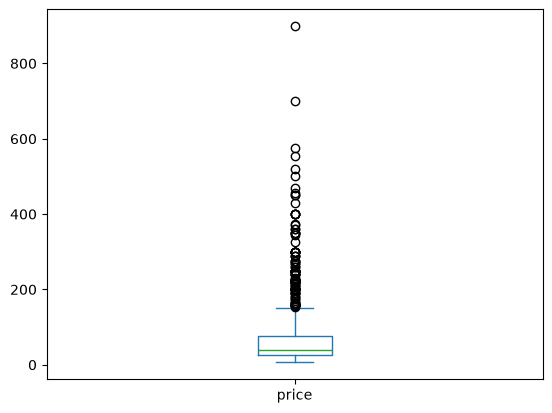

In [ ]:
# Plotting a boxplot to visualize the distribution of prices.

import matplotlib.pyplot as plt

df["price"].plot(kind="box")
plt.show()

Although there are lots of "outliers", these are still valid data points; just the result of a high variation in shoes being sold.

In [ ]:
# Checking eBay categories to see if there are any that are not relevant to the analysis.
df["specificCategory"].unique()

<StringArray>
[                      'Heels',       'Women's Vintage Shoes',
               'Comfort Shoes',                     'Sandals',
                       'Boots',                    'Slippers',
                'Bridal Shoes',                       'Pumps',
      'Bags, Handbags & Cases',                       'Flats',
               'Western Boots',    'Children's Vintage Shoes',
         'Men's Vintage Shoes',               'Women's Boots',
                       'Socks',                'Casual Shoes',
 'Other Japanese Collectibles']
Length: 17, dtype: str

In [ ]:
# Removing invalid categories from the dataframe to focus on relevant data for analysis.
valid_categories = ["Heels", "Bridal Shoes", "Women's Vintage Shoes", "Pumps", "Women's Boots"]
df = df[df["specificCategory"].isin(valid_categories)]

In [11]:
df["specificCategory"].unique()

<StringArray>
['Heels', 'Women's Vintage Shoes', 'Bridal Shoes', 'Pumps', 'Women's Boots']
Length: 5, dtype: str

In [ ]:
# Checking formatting of titles to begin working on size extraction.
df["title"].sample(20).tolist()

['Sebastian Milano Vintage Black Satin Slingback Kitten Heels Italy 37',
 '1980s Sabreé Vintage Red Leather Kitten Heel Size 6.5 Pointed Toe Pumps Retro',
 'VINTAGE JACQUELINE FERRAR MODERN SQUARE TOE ZIPPER SLINGBACK MID-HEELS SHOE 8W',
 'Vintage KATE SPADE NEW YORK  Red/Orange  Corduroy Pump Kitten Heel Size 8.5',
 'Vintage Prevata Cream Leather Pointed Toe Pumps Size 8AA Made in Italy 90s Heels',
 "A Marinelli Special Effects Vintage Y2K Women's Bronze Slingback Heels Size 7.5",
 'GUESS by Marciano Sparkle Vintage Heels Size 6.5',
 'VTG Bijou Black Beaded Slingback Stiletto Pointed Toe Heels Man Made Size 8.5',
 'Vintage 1990s Salvatore Ferragamo Black Camel Leather Kitten Heel Pumps 8B w/Box',
 'Vintage Stuart Weitzman Black Leather Chain Link Kitten Heels Loafers Size 8',
 'Amalfi Italy Black Leather Cap Toe Pumps Women’s Size 6.5 Vintage',
 'Vintage 90s Y2K Purple Suede Kitten Heel Mules Boho Square Toe Brazil 8.5M',
 'Y2K Vintage Seventeen Gabby Black Strappy Shimmer Dress Heels

In [ ]:
# Testing regex pattern to extract shoe sizes from titles. 
# The pattern looks for a number (which may include a decimal) followed by an optional letter (like D, E, etc.) which is common in shoe sizing.
import re

title = "Vintage Apart Leather Pumps Womens 8.5 Beige Bow Square Toe Business Career"
match = re.search(r"\d+(\.\d+)?[A-Z]?", title)
print(match.group() if match else "No match found")

8.5


In [14]:
title2 = "Vtg Stuart Weitzman Leopard Patent Leather Kitten Low Block Heel Square Toe 8.5N"
match2 = re.search(r"\d+(\.\d+)?[A-Z]?", title2)
print(match2.group() if match2 else "No match found")

8.5N


In [ ]:
# Checking for possible issues with regex patterns, namely with date values in names.
title3 = "Vintage 1990's Rodolphe Menudier Slingbacks with Steel Stiletto Heels"
match3 = re.search(r"\d+(\.\d+)?[A-Z]?", title3)
print(match3.group() if match3 else "No match found")

1990


In [ ]:
# Refining and testing regex pattern against multiple titles.
pattern = r"\b\d{1,2}(\.\d+)?[A-Z]?\b"
match = re.search(pattern, title)
match2 = re.search(pattern, title2)
match3 = re.search(pattern, title3)
match4 = re.search(pattern, "VTG Womans Fendi Brown Suede Kitten Heel Mules in Box Size IT 38.5,Heels,115.00")
print(match.group() if match else "No match found")
print(match2.group() if match2 else "No match found")
print(match3.group() if match3 else "No match found")
print(match4.group() if match4 else "No match found")

8.5
8.5N
No match found
38.5


In [ ]:
# Creating a function to extract shoe sizes from titles using the refined regex pattern.
def extract_size(title: str) -> str | None:
    """
    Extract shoe size from a product title and return size.
    If no size is found, return None.
    """
    match = re.search(r"\b\d{1,2}(\.\d+)?[A-Z]?\b", title)
    return match.group() if match else None

df["size"] = df["title"].apply(extract_size)
df[["title", "size"]].sample(15)

,title,size
641,Vintage Fergalicious Fergie Black fabric Y2K Shoe Pumps 8,8
488,Vintage Y2K RedToo Brown/Tan Satin Animal Print Pointy Toe Stilettos Women's 9,9
339,Vintage Anne Klein II Fabric Kitten Heels Size 8 European Old Money Capsule,8
521,"Audrey Vintage Fancy Brown Embellished Flowers 4"" Heels Women's Size 6",4
535,"Amalfi Monica Cork Heels, Women's vintage-style pump made in Italy. Size 8.5N",8.5N
192,"Vintage GIVENCHY Slingback Pumps, Size 6.5, Made In Italy",6.5
36,Vintage Etienne Aigner Ivory/Black Pumps Women's 9M luxury made in Spain,9M
267,Vintage Paloma Italy Black Polka Dot Slingback Kitten Heels Multi Color 8.5,8.5
179,Vintage Y2K tan leather square toe cutout pumps flared heel Two Lips size 7,7
572,Vintage 90s Y2K Donna Karan Pointy Strappy Gray Heels,NaN


When pulling multiple tables, I noticed that titles with phrases like 90s, 80s, etc. were getting misinterpreted as sizes.
Therefore, a more comprehensive extract_size function needs to be created that deals with all of these possible errors.

In [ ]:
def extract_size(title: str) -> str | None:
    """
    Extract shoe size from a product title and return size. 
    If no size is found, return None.
    """
    # Normalize fractions like "6 1/2" into "6.5" before matching
    title = re.sub(r"(\d+)s+1/2", lambda m: str(float(m.group(1)) + 0.5), title)

    # 1. Most confident: explicit "Size" followed by a number (+ optional letters)
    match = re.search(r"size\s*(\d{1,2}(?:\.\d+)?[A-Z]{0,2})", title, re.IGNORECASE)
    if match:
        return match.group(1)

    # 2. Next best: a number with a width number attached (decades don't have this)
    match = re.search(r"\b\d{1,2}(?:\.\d+)?[A-Z]{1,2}\b", title)
    if match:
        return match.group()

    # 3. Fallback: a bare number, but not if followed by an 's (rules out decades)
    match = re.search(r"\b\d{1,2}(?:\.\d+)?\b(?!'?s)", title)
    if match:
        return match.group()

    # 4. Fallback 2: a bare number, but not if followed by an s (rules out decades)
    match = re.search(r"\b\d{1,2}(?:\.\d+)?\b(?!s)", title, re.IGNORECASE)
    if match:
        return match.group()

    return None

test_titles =  [
    "S1 Vintage Paloma Black White Polka Dot Pumps Heels 7AA Made in Italy",
    "Bally Vintage Multicolor Womans Snakeskin Leather Heels,  Ankle Strap Size 6 1/2",
    "Allure Vintage 80's Pump Heels Gray Suede Womens 8.5",
    "Allure Vintage 80's Pump Heels Purple Womens Size 7.5 Abstract Modern Pointed",
    "Vintage Salvatore Ferragamo Boutique black leather heel pump women's size 8B",
    "Vtg 60s Palter Debs Ostrich Patent Leather Pumps Heels Brown 7.5 Classy  Retro,Heels,25.88",
]

for t in test_titles:
    print(extract_size(t), "|", t)

7AA | S1 Vintage Paloma Black White Polka Dot Pumps Heels 7AA Made in Italy
6 | Bally Vintage Multicolor Womans Snakeskin Leather Heels,  Ankle Strap Size 6 1/2
8.5 | Allure Vintage 80's Pump Heels Gray Suede Womens 8.5
7.5 | Allure Vintage 80's Pump Heels Purple Womens Size 7.5 Abstract Modern Pointed
8B | Vintage Salvatore Ferragamo Boutique black leather heel pump women's size 8B
7.5 | Vtg 60s Palter Debs Ostrich Patent Leather Pumps Heels Brown 7.5 Classy  Retro,Heels,25.88


In [ ]:
# Applying the extract_size function to the dataframe to create a new column for shoe sizes.
df["size"] = df["title"].apply(extract_size)

In [ ]:
# Checking how many entries have null values in the "size" column after extraction.
int(df["size"].isnull().sum())

80

The amount here is negligible, and makes sense as some entries did not include size.
I am confident in my extract_size function.

In [ ]:
# Checking a sample of the dataframe to see the extracted sizes alongside titles.
df[["title", "size"]].sample(20)

,title,size
113,Vintage Y2K Christian Siriano For Payless Dark Rose Pump Stiletto Heels Sz 9,9
621,Bandolino Flawless Vintage Women's Stiletto Heels Beige Buckle Accent Tweed.,NaN
95,Leather Slingback Heels 38 Chains Y2K Orange Preppy Vintage Chic Elena Miro,38
486,Carlos Santana NOS Vintage Black Stiletto Heels Closed Toe Pumps Minor Flaw Shoe,NaN
48,Escada Vintage Heels Black Canvas With White Pinstripe Crossover Buckle Size 5.5,5.5
326,Donna Karan Vintage 90's Dark Tangerine Patent Kitten Heel Mules 8M,8M
456,Stuart Weitzman Women's 8B Tan Leather Corset Lace Vintage Kitten Heels,8B
272,Vtg 90s Y2K Round Toe Kitten Heels Mules Womens Sz 7 Dark Whimsigoth Velvet,7
13,Vtg Connie Pumps Ivory Cream Ruched Satin Kitten Heels 6 B New Old Stock NOS 80s,6
565,VTG Y2K 90s Circa Women’s 8 Pumps Brown Suede Pointed Toe Heel Pointy Fairy,8


In [ ]:
# Checking a sample of titles that did not have sizes extracted to see if there are any patterns or issues with the regex.
df[df["size"].isnull()]["title"].sample(30).tolist()

["2026 Women's Retro Dress Leather Cuban Heel Lace Up Shoes Mary Jane Pumps Office",
 'Vintage Off-White Women’s Leather Slingback Pointed Toe Ankle Strap Buckle Heel ',
 'Unique Vintage Prada Kitten Heel Brown With Acorns 1990s',
 'Vintage BCBGMAXAZRIA Brown LeatherHeels',
 'Vintage 1990s Gorgeous YSL Saint Laurent Grey Tan Suede Pointed Toe Pumps WOW!',
 'Vintage Heels Brown/cream As Is Read',
 "Vintage Salvatore Ferragamo Women's Leather Red/White Slingback Spectators",
 'Carlos Santana NOS Vintage Black Stiletto Heels Closed Toe Pumps Minor Flaw Shoe',
 'Vintage women’s Pumps Heels Shoes Yellow',
 'Vintage Michael Kors Black Patent Leather Stilettos',
 'Stuart Weitzman Vintage Gold Lace Peep Toe Leather Sole Heel Made in Spain',
 'Roberto Capucci Bow Pumps Burgundy Leather Kitten Heel Italy Vintage Narrow AA',
 'Vintage 90s Y2K Donna Karan Pointy Strappy Gray Heels  ',
 'Vintage beautiful kitten heels animal print feather shoes Leopard Cheetah',
 'Vintage Vaneli Black Suede Kitten 

In [ ]:
# Pulling a random sample of titles to build a brand list to reference against for a brand extraction function. 
# This will help in identifying brand names in the titles for further analysis.
df["title"].sample(30).tolist()

['Sebastian Milano Vintage Black Satin Slingback Kitten Heels Italy 37',
 "Vintage Stuart Weitzman Women's Toucan Taupe Crepe Fabric Kitten Heels Size 8.5",
 'Vintage 1940s Red Cross Shoe Black Peep Toe Suede Slingback Sandals Heels 6.5',
 'Vintage Amalfi Monica Black Leather Pointed-Toe Kitten Heels w/ Box',
 'Talbots Vintage Betty Apple Green Kitten Heel Pointed Toe Slip Ons Leather 8.5 M',
 'Prima black rhinestone strappy sandal kitten heels y2k vintage mcbling',
 "Vintage Etienne Aigner Ivory/Black Pumps Women's 9M luxury made in Spain",
 "Vintage Bruno Magli Women's Tan Suede Slingback Kitten Heels 8.5 - Made in Italy",
 'Vintage Heels Brown/cream As Is Read',
 'Vintage Mr. Phillips Red & Black Leather Bow Stiletto Pumps Pointed Toe 10',
 'Bettye Mueller Kitten Heels Peacock Print Bow Detail Size 36  US 5.5 6 Vintage',
 'Vintage Y2K 90s Cole Haan Slingback Kitten Heels Patent Leather Square Toe Sz 9',
 'Vtg 90s Y2K Round Toe Kitten Heels Mules Womens Sz 7 Dark Whimsigoth Velvet',


In [ ]:
# First attempt at creating a list of brands from the sample titles. 
# This list was refined and used to extract brand names from the product titles in the dataset.
""" brands = [
    "BCBG",
    "Coup D'etat",
    "Salvatore Ferragamo",
    "Manolo Blahnik",
    "PRADA",
    "Bally Suite",
    "Stuart Weitzman",
    "Barney's",
    "Connie",
    "Andrea",
    "Delman",
    "Ann Marino",
    "Alfani",
    "Giuseppe Zanotti",
    "Christian Dior",
    "Anne Klein",
    "Miu Miu",
    "Robert Clergerie",
    "Timothy Hitsman",
    "Burberry",
    "Nine West",
    "Etienne Aigner",
    "Thom McAn",
    "Emilio Pucci",
    "Escada",
    "Evan Picone",
    "J. Renee",
    "Calvin Klein",
    "Andrew Geller",
    "Ava Ferragamo",
    "Anton Donelli",
    "St. John",
    "Pancaldi",
    "Amanda Smith",
    "Coach",
    "Gucci",
    "Naturalizer",
    "Previa",
    "Bandolino",
    "Betsey Johnson",
    "ZARA",
    "Livingston Bros",
    "John Romaine",
    "Sam & Libby",
    "Botticelli",
    "Talbots x Caressa",
    "Hillard & Hanson",
    "Bruno Magli",
    "Unisa Keyana",
    "Christian Siriano",
    "Charles David",
    "Chanel",
    "Jennifer Moore",
    "Liz Claiborne",
    "Amano",
    "Madden",
    "Bijou",
    "MIA",
    "Kenneth Cole",
    "Margaret J",
    "YSL Saint Laurent",
    "Dolce Zuriel",
    "Vince Camuto",
    "MIchelle D. Brown",
    "Joan & David Brown",
    "Merona",
    "BCBGirls",
    "Pimento",
    "Maggie Sweet",
    "Donna Karan",
    "Moschino",
    "Isaac Mizrahi",
    "Susan Bennis/Warren Edwards",
    "Thos Cortito",
    "Evan-Picone",
    "St. John",
    "Cole Haan",
    "Stuart Weitzman",
    "Hillard & Hanson",
    "Bandolino",
    "Christian Lacroix",
    "Amano",
    "Ralph Lauren",
    "Naturalizer",
    "Adrianna Papell",
    "Rosa",
    "Bakers Marisela",
    "FREE Lance",
    "Nine West",
    "Boutique 9 BT Joy",
    "Allure",
    "Cobbie Cuddlers",
    "Merona",
    "Martinez Valero",
    "Shimano",
    "LEI",
    "Candies",
    "Enzo Angiolini",
    "Sesto Meucci",
    "Amalfi Rangoni",
    "Dolce & Gabbana",
    "Donald J Pliner",
    "Coach",
    "Socialite",
    "Perry ellis",
    "Diane Von Furstenberg",
    "Carlos Santana",
    "Seventeen",
    "Baldinini",
    "Palizzio",
    "Prima",
    "Michelle D",
    "Via Spiga",
    "Norman Kapan",
    "Marc Fisher Dabney",
    "California Magdesians",
    "Emporio Armani",
    "Martinez Valero",
    "Colin Stuart",
    "Proxy",
    "Giorgio Armani",
    "L'Autre",
    "Dolce by Pierre White",
    "Jones New York",
    "Beverly Feldman",
    "Vero Cudio",
    "Liz Claiborne",
    "Laundry By Shelli",
    "Morgan De Toi",
    "Leather Creators",
    "Charles Jourdan",
    "New Wave",
    "Paloma",
    "Caparros",
    "Talbots",
    "Amano",
    "Carlos Falchi",
    "Kenneth Cole",
    "Michelle D Brown",
    "Rodolphe Menudier",
    "Coccini",
    "Miss Bergdorf",
    "Two Lips",
    "Franco Sarto",
    "Parallele",
    "Newport",
    "Caressa",
    "Dolce Gabbana",
    "Ann-Marino",
    "Oscar de la renta",
    "Circa Joan & David",
    "Selby",
    "Ballt",
    "De liso",
    "Nordstrom",
    "Vaneli",
    "IMPO ",
    "Valerie Stevens",
    "Mima Italy",
    "Sutton plaza",
    "Mr. Phillips",
    "Kenzo",
    "Saks Fifth Avenue",
    "St. Vicina",
    "Trotters",
    "Aerosoles",
    "Maserati",
    "Brighton",
    "Deliso",
    "Buccioni by Cosci",
    "Easyspirit",
    "Norman Kaplan",
    "Rocawear",
    "Ellen Tracey",
    "Garolini",
    "Carole Little",
    "Diego Dolcini",
    "Guess",
    "Prevata",
    "Billy Ella",
    "Easy spirit",
    "Fioni",
    "Palter Debs",
    "Pappagallo",
    "BCB Girls",
    "Fendi",
    "Wild Diva",
    "Roberto Capucci",
    "Michael Kors",
    "Salpy",
    "Van Eli",
    "Nickels",
    "Cleo Bottier",
    "A Marinelli",
    "Marco Brelli",
    "BALLY",
    "Amalfi",
    "Diego Di Lucca",
    "Sergio Zelcer",
    "GaLo",
    "Yves Saint Laurent YSL",
    "Colette",
    "Circa Joan and David",
    "Icone",
    "Idea Studio",
    "Fiorangelo",
    "Dollhouse",
    "Romus",
    "Luichiny",
    "Y. Renee",
    "Marc by Marc Jacobs",
    "Louis Vuitton",
    "Kate Spade",
    "Fanfares",
    "Mario Bologna",
    "Givenchy",
    "A. Marinelli",
    "Charlotte Russe",
    "Adrienne",
    "Madamoiselle",
    "Mootsies Tootsies",
    "Sabreé",
    "Dione",
    "Juicy Couture",
    "Boutique 9",
    "Nando Muzi",
    "Nine-west",
    "Harve Benard",
    "Monzo & Franco",
    "WILD PAIR",
    "Bettye Mueller",
    "Ferragamo",
    "Walter Steiger",
    "Mootsie Tootsie",
    "Lara Manni",
    "Jimmy Choo",
    "Fabulous Furs",
    "Juliano",
    "RioWomen's",
    "Unisa",
    "Jean Paul Barriol",
    "No Boundaries",
    "Classiques Entier",
    "Nina",
    "BALDAN",
    "BUMPER",
    "Dream Step",
    "Ann Taylor",
    "Cameo Room",
    "TOUCH-UPS",
    "Joyce Brown",
    "Chloe",
    "Roma Last Marquise",
    "Versani",
    "Brocade",
    "Barney's",
    "Nicole Miller",
    "SPICY",
    "Vanna",
    "BODEN",
    "Audrey",
    "KF Ltd",
    "St John",
    "Rapallo",
    "Barbie",
    "Crown",
    "Apple Bottoms",
    "Linea Paolo",
    "Bratz",
    "JG Hook",
    "Timothy's Collection",
    "Chelsea Crew",
    "Coup D'etat",
    "Elena Miro",
    "Jacqueline Ferrar",
    "Giraudon",
    "Eddie Bauer",
    "Balenciaga",
    "Tweedies",
    "Joan & David",
    "Karen Scott",
    "La Patti",
    "Anne Michelle",
    "Tory Burch",
    "Donald Pliner",
    "Pencey Neiman",
    "Barney's",
    "Off-White",
    "Magdesians",
    "Gap",
    "Birkenstock",
    "Fashion Nova",
    "Maripe",
    "Richard Tyler",
    "LARIO",
    "Fergalicious",
    "Gianni Binni",
    "Auditions",
    "Florsheim",
    "Salvatore Ferragammo",
    "Edouard Jerrold",
    "Dolce&Gabbana",


]

brands = list(set(brands))
print(len(brands))"""

' brands = [\n    "BCBG",\n    "Coup D\'etat",\n    "Salvatore Ferragamo",\n    "Manolo Blahnik",\n    "PRADA",\n    "Bally Suite",\n    "Stuart Weitzman",\n    "Barney\'s",\n    "Connie",\n    "Andrea",\n    "Delman",\n    "Ann Marino",\n    "Alfani",\n    "Giuseppe Zanotti",\n    "Christian Dior",\n    "Anne Klein",\n    "Miu Miu",\n    "Robert Clergerie",\n    "Timothy Hitsman",\n    "Burberry",\n    "Nine West",\n    "Etienne Aigner",\n    "Thom McAn",\n    "Emilio Pucci",\n    "Escada",\n    "Evan Picone",\n    "J. Renee",\n    "Calvin Klein",\n    "Andrew Geller",\n    "Ava Ferragamo",\n    "Anton Donelli",\n    "St. John",\n    "Pancaldi",\n    "Amanda Smith",\n    "Coach",\n    "Gucci",\n    "Naturalizer",\n    "Previa",\n    "Bandolino",\n    "Betsey Johnson",\n    "ZARA",\n    "Livingston Bros",\n    "John Romaine",\n    "Sam & Libby",\n    "Botticelli",\n    "Talbots x Caressa",\n    "Hillard & Hanson",\n    "Bruno Magli",\n    "Unisa Keyana",\n    "Christian Siriano",\n    

While/after building my brand_extraction function, I found this brand list to be very flawed. 
I initially included typos/different spellings, and included brands multiple times.
I realized that it would be hard to consolidate brands with typos (making sure Ferragammo and Ferrragammmo were counted as the same brand),
so I revised my list and created a fuzzy matching function to consolidate these typos/error cases.

In [143]:
brands = [
"BCBG",
"Coup D'etat",
"Salvatore Ferragamo",
"Manolo Blahnik",
"PRADA",
"Bally Suite",
"Stuart Weitzman",
"Barney's",
"Connie",
"Andrea",
"Delman",
"Ann Marino",
"Alfani",
"Giuseppe Zanotti",
"Christian Dior",
"Anne Klein",
"Miu Miu",
"Robert Clergerie",
"Timothy Hitsman",
"Burberry",
"Nine West",
"Etienne Aigner",
"Thom McCann",
"Emilio Pucci",
"Escada",
"Evan Picone",
"J. Renee",
"Calvin Klein",
"Andrew Geller",
"Ava Ferragamo",
"Anton Donelli",
"St. John",
"Pancaldi",
"Amanda Smith",
"Coach",
"Gucci",
"Naturalizer",
"Previa",
"Bandolino",
"Betsey Johnson",
"ZARA",
"Livingston Bros",
"John Romaine",
"Sam & Libby",
"Botticelli",
"Talbots x Caressa",
"Hillard & Hanson",
"Bruno Magli",
"Unisa Keyana",
"Christian Siriano",
"Charles David",
"Chanel",
"Jennifer Moore",
"Liz Claiborne",
"Amano",
"Madden",
"Bijou",
"MIA",
"Kenneth Cole",
"Margaret J",
"YSL Saint Laurent",
"Dolce Zuriel",
"Vince Camuto",
"Michelle D Brown",
"Joan & David",
"Merona",
"BCBGirls",
"Pimento",
"Maggie Sweet",
"Donna Karan",
"Moschino",
"Isaac Mizrahi",
"Susan Bennis/Warren Edwards",
"Thos Cortito",
"Cole Haan",
"Christian Lacroix",
"Ralph Lauren",
"Adrianna Papell",
"Rosa",
"Bakers Marisela",
"FREE Lance",
"Boutique 9 BT Joy",
"Allure",
"Cobbie Cuddlers",
"Martinez Valero",
"Shimano",
"LEI",
"Candies",
"Enzo Angiolini",
"Sesto Meucci",
"Amalfi Rangoni",
"Dolce & Gabbana",
"Donald J Pliner",
"Socialite",
"Perry Ellis",
"Diane Von Furstenberg",
"Carlos Santana",
"Seventeen",
"Baldinini",
"Palizzio",
"Prima",
"Michelle D",
"Via Spiga",
"Norman Kaplan",
"Marc Fisher Dabney",
"California Magdesians",
"Emporio Armani",
"Colin Stuart",
"Proxy",
"Giorgio Armani",
"L'Autre",
"Dolce by Pierre White",
"Jones New York",
"Beverly Feldman",
"Vero Cudio",
"Laundry By Shelli",
"Morgan De Toi",
"Leather Creators",
"Charles Jourdan",
"New Wave",
"Paloma",
"Caparros",
"Talbots",
"Carlos Falchi",
"Rodolphe Menudier",
"Coccini",
"Miss Bergdorf",
"Two Lips",
"Franco Sarto",
"Parallele",
"Newport",
"Caressa",
"Circa Joan & David",
"Selby",
"Ballt",
"Deliso",
"Nordstrom",
"Vaneli",
"IMPO",
"Valerie Stevens",
"Mima Italy",
"Sutton plaza",
"Mr. Phillips",
"Kenzo",
"Saks Fifth Avenue",
"St. Vicina",
"Trotters",
"Aerosoles",
"Maserati",
"Brighton",
"Buccioni by Cosci",
"Easy Spirit",
"Rocawear",
"Ellen Tracey",
"Garolini",
"Carole Little",
"Diego Dolcini",
"Guess",
"Prevata",
"Billy Ella",
"Fioni",
"Palter Debs",
"Pappagallo",
"Fendi",
"Wild Diva",
"Roberto Capucci",
"Michael Kors",
"Salpy",
"Nickels",
"Cleo Bottier",
"A. Marinelli",
"Marco Brelli",
"BALLY",
"Amalfi",
"Diego Di Lucca",
"Sergio Zelcer",
"GaLo",
"Colette",
"Idea Studio",
"Fiorangelo",
"Dollhouse",
"Romus",
"Luichiny",
"Marc by Marc Jacobs",
"Louis Vuitton",
"Kate Spade",
"Fanfares",
"Mario Bologna",
"Givenchy",
"Charlotte Russe",
"Adrienne",
"Madamoiselle",
"Mootsies Tootsies",
"Sabreé",
"Dione",
"Juicy Couture",
"Boutique 9",
"Nando Muzi",
"Harve Benard",
"Monzo & Franco",
"WILD PAIR",
"Bettye Mueller",
"Walter Steiger",
"Lara Manni",
"Jimmy Choo",
"Fabulous Furs",
"Juliano",
"RioWomen's",
"Unisa",
"Jean Paul Barriol",
"No Boundaries",
"Classiques Entier",
"Nina",
"BALDAN",
"BUMPER",
"Dream Step",
"Ann Taylor",
"Cameo Room",
"TOUCH-UPS",
"Joyce Brown",
"Chloe",
"Roma Last Marquise",
"Versani",
"Brocade",
"Nicole Miller",
"SPICY",
"Vanna",
"BODEN",
"Audrey",
"KF Ltd",
"Rapallo",
"Barbie",
"Crown",
"Apple Bottoms",
"Linea Paolo",
"Bratz",
"JG Hook",
"Timothy's Collection",
"Chelsea Crew",
"Elena Miro",
"Jacqueline Ferrar",
"Giraudon",
"Eddie Bauer",
"Balenciaga",
"Tweedies",
"Joan & David",
"Karen Scott",
"La Patti",
"Anne Michelle",
"Tory Burch",
"Pencey Neiman",
"Off-White",
"Gap",
"Birkenstock",
"Fashion Nova",
"Maripe",
"Richard Tyler",
"LARIO",
"Fergalicious",
"Gianni Binni",
"Auditions",
"Icone",
"Florsheim",
"Edouard Jerrold",
"Gianni Bini",

]

brands = list(set(brands))
print(len(brands))


264


In [ ]:
# Creating a function to extract brand names from product titles using the list of known brands. 
def extract_brand(title: str) -> str | None:
    """
    Extract brand name from a product title and return brand. 
    If no brand is found, return None.
    """
    for brand in brands:
        if brand.lower() in title.lower():
            return brand
    return None

df["brand"] = df["title"].apply(extract_brand)

In [145]:
df["brand"].isnull().sum()

np.int64(153)

In [146]:
df[["title", "brand"]].sample(20)

,title,brand
128,Vtg Clear Silver Square Toe Clear Heel Rhinestone Studded Strap Detail Y2K 7.5,NaN
258,Size 8 Bruno Magli Blue Leather Slingback Peep Toe Heel Buckle Brand New VTG,Bruno Magli
433,Vintage Kenneth Cole d'Orsay Black Kitten Heel Point Toe Size 9,Kenneth Cole
284,Vintage Kitten Heels Pumps 10 Italy Pointed Square Toe Perforated Suede Leather,NaN
552,D' ORINETTI New York Vtg 80's Black Silk Pump Rhinestones Womens 8.5 DAMAGED,NaN
363,TOUCH-UPS Royal Blue Satin Heels 6.5M VINTAGE 80s Shoes Kitten Stiletto EUC!!,TOUCH-UPS
41,Nine West Paolo Batacchi pearl Leather Square Toe Block Heel Pumps Spain vintage,Nine West
359,Vintage Chanel Two Toned Leather Kitten Heels Size 37 US 7 Capped Toe,Chanel
997,Vintage Cobbie Cuddlers White Woven Leather Huarache Sandals NWT Size 14 Deadstk,Cobbie Cuddlers
524,NIB Vintage WILD PAIR sz 6.5 METAL 5434 GIL-35 Lace Up Tie Black Stiletto Shoes,WILD PAIR


In [147]:
df[df["brand"].isnull()]["title"].sample(40).tolist()

['Vintage Womens Heels 5.5 Black Fuzzy Peep Toe Chic Wedding Guest Event Formal',
 'Vintage 90s Y2K Classic Black Suede Mary Jane Block Heel Pumps Size 9M',
 'Vintage 90s Jasmin Womens5 Black Faux Suede Pointed Toe Pumps 2" Kitten Heels',
 'Vintage Lot Of 8 Pairs Of Women’s Pointy Toe Heels Size 6 Various Colors Neutral',
 'Y2K vintage 2000s red leather kitten heels ecco twee | Size EUR 36',
 "Acapulco Vintage 50's 60's Colorblock Canvas Kitten Heel Sandals Mexico",
 'Vintage 1950s leather wing tip heels 7 tan black leather pumps slingback kitten',
 'Vintage Summer RioWomen’s Studded Black Suede Kitten Heels Size 8',
 "Vintage Suede Kitten Heel Pumps Bow Round Toe Classic Shoes Women's Size 37",
 'Silver  Nubuck Leather Heels EU 40 / US 9  – Pointed Toe Y2K Vintage',
 'Vtg Ann-Marino Black Snake 2.25" Kitten Heels Gold studded Classy Retro sz 7 New',
 'Vintage Italian Leather Pumps EU 39 (8-9 US) Cognac 2”Kitten Heel Made in Italy',
 'Dolce Gabbana Rose Floral Satin Vintage Kitten Heel

In [148]:
%pip install rapidfuzz

from rapidfuzz import process

canonical_brands = list(set(brands))

def fuzzy_match_brand(name: str, threshold: int = 70) -> str | None:
    if not name:
        return None
    match = process.extractOne(name, canonical_brands)
    if match and match[1] >= threshold:
        return match[0]
    return name

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3.14t.exe -m pip install --upgrade pip


In [149]:
df["brand"] = df["brand"].apply(fuzzy_match_brand)

In [150]:
pd.options.display.max_rows = 300
df["brand"].value_counts()

brand
Stuart Weitzman                32
Salvatore Ferragamo            18
Bruno Magli                    13
PRADA                          11
Anne Klein                     11
Etienne Aigner                 10
St. John                       10
Nine West                       7
BALLY                           6
Ann Marino                      6
Bandolino                       6
Kenneth Cole                    6
Talbots                         6
BCBG                            5
Escada                          5
Icone                           5
Kate Spade                      5
Manolo Blahnik                  4
Amalfi                          4
BCBGirls                        4
Donald J Pliner                 4
Cole Haan                       4
Dolce & Gabbana                 4
Gucci                           3
Andrea                          3
Delman                          3
J. Renee                        3
Naturalizer                     3
Betsey Johnson                  3
Caressa 

In [151]:
print(fuzzy_match_brand("Salvatore Ferragammo"))

Salvatore Ferragamo


In [152]:
print(fuzzy_match_brand("BCB Girls"))

BCBGirls


In [153]:
print(fuzzy_match_brand("Dolce by Pierre"))

Dolce by Pierre White


In [154]:
print(fuzzy_match_brand("Magdesians"))

California Magdesians


In [155]:
# pull data to build color matching function
df["title"].sample(30).tolist()

['Vintage Y2K Christian Siriano For Payless Dark Rose Pump Stiletto Heels Sz 9',
 'VTG Nine-West “Elsa” Pumps Black Suede w/Tassels-&-CROC Accent Size 7.5 NIB',
 'Y2K Vintage Seventeen Gabby Black Strappy Shimmer Dress Heels Size 7',
 'Unique Vintage Prada Kitten Heel Brown With Acorns 1990s',
 'VTG Amano Gold Women’s High Heel Shoes Size 8.5 N',
 'Vintage Enzo Angiolini Brown Leather Fringe Heels Double Buckle Pumps Size 7M',
 'Vintage Giorgio Armani Beige Pointed Toe Ankle Strap Leather Stiletto Pumps 39',
 'Vintage Y2K Escada Strappy Logo Heel Sandals Size 38',
 'Donald J Pliner Couture Kitten Heels Metea Bow Black Suede Height 1.75" Size 6.5',
 "Vtg 70's Brown Leather Strappy Slingback Cut Out Ankle Strap Hippie Heels Size 8",
 'Vintage 90s Hillard & Hanson Strappy Heels Size 7.5 Black Chunky Heel Square Toe',
 'Vtg Stuart Weitzman Leopard Patent Leather Kitten Low Block Heel Square Toe 8.5N',
 'Vintage Jones New York Black Gold Stiletto Heels Ankle Strap Buckle Women’s 6.5',
 'Emp

In [156]:
colors = [
    "Purple",
    "Gold",
    "Red",
    "Black",
    "White",
    "Beige",
    "Pink",
    "Silver",
    "Tan",
    "Bronze",
    "Brown",
    "Gray",
    "Grey",
    "Blue",
    "Multicolor",
    "Yellow",
    "Green",
    "Mauve",
    "Pearl",
    "Leopard",
    "Snakeskin",
    "Croc",
    "Taupe",
    "Paisley",
    "Floral",
    "Coral",
    "Rose",
    "Orange",
    "Navy",
    "Plaid",
    "Camel",
    "Ivory",
    "Cream",
    "Various Colors",
    "Khaki",
    "Rainbow",
    "Snake print",
    "Tortoise",
    "Burgundy",
    "Blush",
    "Colorblock",

]

In [157]:
def extract_colors(title: str) -> str | None:
    found_colors = []
    for color in colors:
        if color.lower() in title.lower():
            found_colors.append(color)

    if len(found_colors) == 1:
        return found_colors[0]
    elif len(found_colors) > 1:
        return "Multicolor"
    else:
        return None

df["colors"] = df["title"].apply(extract_colors)

In [158]:
df[["title", "colors"]].sample(20)

,title,colors
470,vintage 1970s pink leather mules 70s high heel shoes stilettos size 5 scalloped,Pink
984,Vintage Y2K Chunky Platform High Heel Bratz Shoes Sandals Size 9,NaN
211,Vtg LEI Brown Platform Loafer Heels Chunky Heel Buckle Y2K Bratz Academia sz 7,Brown
579,Spicy Snake Print Stiletto Heels - Size 8.5-Vintage,Snake print
87,Prada Vintage Y2K Black Buckle Pumps Size 37.5 US 7 6.5,Black
416,Vintage 1980s Flings White Leather Kitten heels Size 10,White
565,VTG Y2K 90s Circa Women’s 8 Pumps Brown Suede Pointed Toe Heel Pointy Fairy,Brown
625,Allure Vintage 80's Pump Heels Purple Womens Size 7.5 Abstract Modern Pointed,Purple
591,Vintage Reformation Brooke Slingback Tie Heels Size US 7 - NEW IN A BOX,NaN
116,Vintage Etienne Aigner Brett Leather Pumps Women’s 7.5 NLow Heel Shoes Peeling,NaN


In [159]:
df[df["colors"].isnull()]["title"].sample(20).tolist()

["Birkenstock Arizona Mocha Birkibuc Leather Men's and Women's Sandals Select Size",
 'VTG Robert Clergerie Paris Metallic Architectural Mule US 9 Made In France Rare',
 '🎨 ARCHIVAL GRAIL Vintage 90s Moschino Beaded Suede Mules - 6/36',
 'Guess Marciano Heels Womens Size 8 Vintage Stiletto Leather Platform 4.5" High',
 'Vintage  ZIGI SOHO STRIVE Jewels Sparkling Ankle Strap 5”H Heels Size 7.5',
 'New Y2K VINTAGE CALVIN KLEIN PORTIA LEATHER METALLIC Slingback Heels Sz 8 M',
 'Vintage Joan & David Handmade Suede Leather Fringed Kitten Heels Made in Italy',
 'GUESS by Marciano Sparkle Vintage Heels Size 6.5',
 'Christian Lacroix Vintage Polka Dot Kitten Heel Sandal 38',
 "Amalfi Monica Cork Heels, Women's vintage-style pump made in Italy. Size 8.5N",
 'Vintage Salvatore Ferragamo Calfskin Leather "Carla" Kitten Heels Size 5 1/2',
 'Vintage Maripe velvet kitten heels',
 'Vintage Color Block 7.5 M Nine West Platform Leather Sling Back Stiletto Heels',
 'Fantastic Vtg 60’s Middle Eastern Poi

In [160]:
sum(df["colors"].isnull())

102

In [164]:
# consolidate colors into groups
color_groups = {
    "Red": "Red",
    "Rose": "Red",
    "Burgundy": "Red",
    "Orange": "Orange",
    "Yellow": "Yellow",
    "Green": "Green",
    "Blue": "Blue",
    "Navy": "Blue",
    "Purple": "Purple",
    "Mauve": "Purple",
    "Gold": "Gold",
    "Silver": "Silver",
    "Bronze": "Bronze",
    "Multicolor": "Multicolor",
    "Various Colors": "Multicolor",
    "Rainbow": "Multicolor",
    "Colorblock": "Multicolor",
    "Black": "Black",
    "White": "White",
    "Pearl": "White",
    "Ivory": "White",
    "Cream": "White",
    "Tan": "Tan",
    "Beige": "Tan",
    "Taupe": "Tan",
    "Camel": "Tan",
    "Khaki": "Tan",
    "Brown": "Brown",
    "Pink": "Pink",
    "Blush": "Pink",
    "Coral": "Pink",
    "Gray": "Gray",
    "Grey": "Gray",
    "Leopard": "Animal Print",
    "Snakeskin": "Animal Print",
    "Snake print": "Animal Print",
    "Tortoise": "Animal Print",
    "Croc": "Animal Print",
    "Paisley": "Pattern",
    "Floral": "Pattern",
    "Plaid": "Pattern",

}

def normalize_color(colors: str | None) -> str | None:
    if colors is None:
        return None
    return color_groups.get(colors, colors)

df["colors"] = df["colors"].apply(normalize_color)

In [165]:
extract_colors("Vintage Betsey Johnson Navy Blue Red Bow Snakeskin Stiletto Y2K Heels Size 5.5")

'Multicolor'

In [166]:
df[["title","brand", "colors"]].sample(20)

,title,brand,colors
13,Vtg Connie Pumps Ivory Cream Ruched Satin Kitten Heels 6 B New Old Stock NOS 80s,Connie,Multicolor
399,Vintage Louis Vuitton Y2K Kitten Heels 38,Louis Vuitton,NaN
319,Vintage 90s Kitten Heel Mules Size 7.5 Black Red Square Toe Italian Sculptural,NaN,Multicolor
285,VTG Gold Qualicraft Kitten Heels 1940s 1950s Size 8AAA Narrow Retro,NaN,Gold
641,Vintage Fergalicious Fergie Black fabric Y2K Shoe Pumps 8,Fergalicious,Black
538,$450 Sergio Zelcer White Leather Flower Slingback Heels Vintage sz 9 Day-Dinner,Sergio Zelcer,White
0,Vintage pinup Stiletto Heels Polka Dot Bow Ankle Strap Open Toe,NaN,NaN
117,Vintage 90s Strappy Heels Size 9.5 Black Chunky Square Toe Hillard & Hanson,Hillard & Hanson,Black
253,Unique Vintage Prada Kitten Heel Brown With Acorns 1990s,PRADA,Brown
46,Women's Mid Block Heel Slip On Round Toe Retro Wing Tip Formal Pumps Shoes Plus,NaN,NaN


In [167]:
df[["title","brand", "colors", "size", "price"]].sample(20)

,title,brand,colors,size,price
449,Vtg Gucci Black Patent Leather GG Logo Kitten Heels 36.5,Gucci,Black,36.5,220.00
153,Dolce Zuriel 100% Leather Square Toe Pumps with Kitten Heels - Green (size 10),Dolce Zuriel,Green,10,64.99
50,Vintage Trotters Jaime Pumps Orig Box Black Leather Womens 8.5 M Victorian Retro,Trotters,Black,8.5,22.40
38,Vintage 2000s Mustard Yellow Faux Suede Retro Block Heel Pumps 8.5,NaN,Yellow,8.5,19.00
239,"MARCO BRELLI VINTAGE HARVARD BLACK PUMPS 3/4"" HEEL 7M WOMEN'S NOS GOLDWATERS",Marco Brelli,Multicolor,7M,32.90
386,Y2K Vintage Black Pointed Toe Slingback Kitten Heels Baddie Going Out Size 6,NaN,Black,6,33.95
596,Vintage Stuart Weitzman Love Knot Black Rhinestone Heels Size 6 Origin: $185,Stuart Weitzman,Black,6,65.00
474,Miss Bergdorf Vintage Dress Heels Black Textured Fabric Leather Soles Italy 8.5B,Miss Bergdorf,Multicolor,8.5B,31.49
379,VINTAGE NINE WEST KITTEN HEEL - LEATHER & REAL COWHIDE - SIZE 5.5,Nine West,NaN,5.5,34.00
477,GUESS by Marciano Sparkle Vintage Heels Size 6.5,Guess,NaN,6.5,30.00
